# Time Averaging of 1-min Data (floor / ceiling / center)
# 分钟级数据时间平均（floor / ceiling / center）

This notebook loads one monthly archive (**§2**), runs the same **solpos → clear-sky → `qc_test` → `qc_mask`** pipeline as **`2.quality_control.ipynb`** in brief (**§3**), then shows averaging on the dataset via **`BSRNDataset.average`** (**§4**). The rest focuses on **`pretty_average`** and direct `DataFrame` use.

**§5** explains how `pretty_average` differs from `pandas.resample` (windows, monthly label trim, coverage, `match_ceiling_labels`); **§5.1** uses **`ds.data()`** (QC-masked minute data after **§3**) for alignments; **§5.2** compares **`match_ceiling_labels`** for **center** only; **§5.3** tabulates **samples per 1 h interval** (floor / ceiling / center). **§6** applies 1 h averaging to the QIQ month. **§7–8** plot comparisons (plots at the end of the workflow).

本笔记本加载月度存档（**§2**），在 **§3** 中简要复现与 **`2.quality_control.ipynb`** 相同的 **solpos → clear-sky → `qc_test` → `qc_mask`** 流程，随后在 **§4** 演示 **`BSRNDataset.average`** 的**数据集管线**；其后以 **`pretty_average`** 与直接操作 **`DataFrame`** 为主。

**§5** 说明差异（窗、月界裁剪、覆盖、`match_ceiling_labels`）；**§5.1** 用 **§3** 后 **`ds.data()`**（经 **`qc_mask`** 的分钟数据）比较对齐；**§5.2** 仅比较 **center** 的 **`match_ceiling_labels`**；**§5.3** 统计每个 1h 窗的**样本数**（floor / ceiling / center）。**§6** 对 QIQ 全月做 1 小时平均。**§7–8** 为对比图（图放在工作流末尾）。


## 1. Import libraries / 导入库

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

import bsrn
from bsrn.utils import pretty_average

# Same sample file pattern as 4.clear_sky_detection.ipynb
INPUT_FILE = "/Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq0824.dat.gz"

pd.options.display.max_columns = None


## 2. Load QIQ August data / 加载 QIQ 8 月数据

In [2]:
if os.path.exists(INPUT_FILE):
    ds = bsrn.BSRNDataset.from_file(INPUT_FILE)
    stn = ds.station_code
    print(
        f"Data for {stn} loaded successfully ({ds.year}-{ds.month:02d})."
    )
    display(ds.data().head())
else:
    raise FileNotFoundError(
        f"File not found: {INPUT_FILE}. Current working directory: {os.getcwd()}"
    )

Data for QIQ loaded successfully (2024-08).


,ghi,bni,dhi,lwd,temp,rh,pressure
2024-08-01 00:00:00+00:00,105.0,0.0,106.0,421.0,25.2,70.0,981.0
2024-08-01 00:01:00+00:00,108.0,0.0,109.0,422.0,25.2,71.0,981.0
2024-08-01 00:02:00+00:00,112.0,0.0,113.0,421.0,25.2,70.0,981.0
2024-08-01 00:03:00+00:00,113.0,0.0,114.0,421.0,25.2,70.0,981.0
2024-08-01 00:04:00+00:00,116.0,0.0,117.0,421.0,25.2,71.0,981.0


## 3. Solar geometry, clear-sky (REST2), and QC / 太阳几何、晴空（REST2）与 QC

We use the **same pipeline** as **`2.quality_control.ipynb`**: ``BSRNDataset.solpos``, ``BSRNDataset.clear_sky`` (here ``model='rest2'`` with MERRA-2 via Hugging Face), then ``BSRNDataset.qc_test`` followed immediately by ``BSRNDataset.qc_mask`` (failed irradiance → NaN, standard ``flag*`` columns dropped). Read **`2.quality_control`** for details; we do not tabulate flags here. **`ds.data()`** after **§3** is the **QC-masked** minute frame for **`pretty_average`** from **§5** onward; **§4** calls **`average`** on **`ds.model_copy(deep=True)`** so **`ds`** stays at minute resolution.

与 **`2.quality_control.ipynb`** 使用**相同流程**：``BSRNDataset.solpos``、``BSRNDataset.clear_sky``（此处 ``model='rest2'``，MERRA-2 经 Hugging Face）、再 ``BSRNDataset.qc_test`` 并紧接着 ``BSRNDataset.qc_mask``（失败辐照度置 NaN，删除标准 ``flag*`` 列）。细节见 **`2.quality_control`**；此处不汇总标记列。**§3** 后的 **`ds.data()`** 为**已 QC 掩膜**的分钟帧，供 **§5** 起 **`pretty_average`** 使用；**§4** 在 **`ds.model_copy(deep=True)`** 的副本上调用 **`average`**，以免 **`ds`** 被替换为较粗时间索引。


In [3]:
# Same pipeline as 2.quality_control.ipynb / 与 2.quality_control 相同流程
ds.solpos()
ds.clear_sky(model="rest2")
ds.qc_test()
ds.qc_mask()

display(ds.data()[["ghi", "ghi_clear", "zenith"]].head())


Fetching MERRA-2 from Hugging Face: qiq/qiq0824_merra2.parquet


,ghi,ghi_clear,zenith
2024-08-01 00:00:00+00:00,105.0,507.439814,54.881
2024-08-01 00:01:00+00:00,108.0,509.994881,54.717
2024-08-01 00:02:00+00:00,112.0,512.545982,54.553
2024-08-01 00:03:00+00:00,113.0,515.077560,54.390
2024-08-01 00:04:00+00:00,116.0,517.620641,54.226


## 4. Pipeline averaging: `BSRNDataset.average` / 管线平均：`BSRNDataset.average`

On a **`BSRNDataset`**, call **`average(freq, ...)`** on the **dataset** (not on the bare `DataFrame` from **`data()`**). It delegates to **`pretty_average`** on the cached frame, then **replaces** that cache with the coarser-index result. **§5+** still need minute-level **`ds`**, so we **`model_copy(deep=True)`** (Pydantic) and call **`average`** on the copy—same columns as **`ds.data()`** after **§3** (including **QC-masked** irradiance).

在 **`BSRNDataset`** 上调用 **`average(freq, …)`**（**不要**对 **`data()`** 返回的裸 **`DataFrame`** 调用）。内部以 **`pretty_average`** 替换缓存。**§5 及以后**仍需要分钟级 **`ds`**，故先用 **`model_copy(deep=True)`**（Pydantic）深拷贝再 **`average`**，副本与 **§3** 后 **`ds.data()`** 列一致（含 **QC 掩膜**后的辐照度）。

When you are done with minute data, you may call **`average`** on **`ds`** itself instead of a copy.

若不再需要分钟数据，也可直接在 **`ds`** 上调用 **`average`**，无需副本。

In [4]:
from IPython.display import display

ds_h = ds.model_copy(deep=True)
ds_h.average("1h", alignment="ceiling")
display(ds_h.data()[["ghi", "ghi_clear", "zenith"]].head())


,ghi,ghi_clear,zenith
2024-08-01 01:00:00+00:00,203.385965,581.242271,49.990333
2024-08-01 02:00:00+00:00,380.630435,706.014627,41.060483
2024-08-01 03:00:00+00:00,303.216667,791.170072,33.993883
2024-08-01 04:00:00+00:00,230.416667,826.488629,30.319967
2024-08-01 05:00:00+00:00,237.150000,817.447416,31.301850


## 5. What `pretty_average` does / `pretty_average` 的语义

`bsrn.utils.averaging.pretty_average` implements **explicit labeled windows** — it is **NOT**
`pandas.DataFrame.resample`. For each output label time `L` (bin length `Δ` from `freq`), data rows are selected with a rule that depends on **`alignment`**.

`pretty_average` 使用**显式标签窗**，**不是** `resample`。对每个输出标签时刻 `L`（`freq` 给出窗长 `Δ`），按 **`alignment`** 选取行。

### Windows / 窗定义

| Alignment | Interval | Role of `L` |
| :--- | :--- | :--- |
| **floor** | $[L, L+\Delta)$ | Label at **left** edge / 标签在左端 |
| **ceiling** | $(L-\Delta, L]$ | Label at **right** edge / 标签在右端 |
| **center** | $[L-\Delta/2+\mathrm{res},\, L+\Delta/2]$ | Label at **center**; `res` = native step (1 or 3 min inferred for LR0100 if omitted) / 标签居中；`res` 为原生步长（LR0100 可省略，由索引推断 1 或 3 分钟） |

### Monthly label trim / 月界标签裁剪

The regular grid from `floor(min)` … `ceil(max)` at `freq` is **trimmed** so edge bins do not straddle month boundaries (`lo` / `hi` from the data index). **floor** drops labels at the high edge; **ceiling** drops at the low edge. For **center**, choose the same trim as **ceiling** or **floor** via **`match_ceiling_labels`** (default `True`).

规则网格会**裁剪**，避免边界小时跨月。**center** 与 ceiling 或 floor **共用**哪一套裁剪由 **`match_ceiling_labels`** 控制（默认与 ceiling 一致）。

### Coverage / 覆盖

A numeric aggregate is emitted only if enough rows are “valid” (numeric columns: at least one finite value in that row).

- **floor / ceiling:** valid count must be **>** half of the nominal step count $\approx \Delta/\mathrm{res}$.
- **center:** valid count must be **>** half of **rows in the window** (not the nominal count).

Otherwise the row is still emitted but values are **NaN**.

### Inputs / 输入

- **`DatetimeIndex`** is required.\n

**Below:** **§5.1** uses **`ds.data()`** for floor/ceiling/center; **§5.2** compares **`match_ceiling_labels`** (center only); **§5.3** counts **samples per 1 h** window. **§6** applies `pretty_average` for the workflow plots.

**下方：****§5.1** 用 **`ds.data()`** 比较 floor/ceiling/center；**§5.2** 比较 **`match_ceiling_labels`**（仅 center）；**§5.3** 统计每 1h 窗**样本数**；**§6** 为工作流整月应用。


### 5.1 Case A — full month, different label times / 整月、不同标签时刻

**All rows** in **`ds.data()`** after **§3** (one station-month from the archive). `freq='1h'`: **floor** / **ceiling** / **center** differ in where the hour label sits; counts can differ slightly at month edges.

**§3** 后的 **`ds.data()`** 全表（存档中的单站单月）。`freq='1h'`：**floor** / **ceiling** / **center** 的标签时刻不同；月界附近行数可略有差异。


In [5]:
# ds.data() after §3: one station-month (see INPUT_FILE). / §3 后 ds.data() 为单站单月（见 INPUT_FILE）
df_a = ds.data()[["ghi", "zenith"]].copy()
freq = "1h"

f_a = pretty_average(df_a, freq, alignment="floor")
c_a = pretty_average(df_a, freq, alignment="ceiling")
z_a = pretty_average(df_a, freq, alignment="center")

print("Case A — 1 h labels (UTC) on the loaded month:")
print(f"  native rows in window: {len(df_a)}")
for name, s in [("floor", f_a), ("ceiling", c_a), ("center", z_a)]:
    print(f"  {name:7s}: n={len(s):4d}  first={s.index[0]}  last={s.index[-1]}")


Case A — 1 h labels (UTC) on the loaded month:
  native rows in window: 44640
  floor  : n= 744  first=2024-08-01 00:00:00+00:00  last=2024-08-31 23:00:00+00:00
  ceiling: n= 744  first=2024-08-01 01:00:00+00:00  last=2024-09-01 00:00:00+00:00
  center : n= 744  first=2024-08-01 01:00:00+00:00  last=2024-09-01 00:00:00+00:00


### 5.2 Case B — `match_ceiling_labels` usage / `match_ceiling_labels` 用法

For **`alignment='center'`** only: **`match_ceiling_labels`** chooses whether monthly label trimming follows **ceiling** (default) or **floor**. Compare the two **`center`** outputs (row counts and first/last labels).

仅 **`alignment='center'`**：**`match_ceiling_labels`** 决定月界裁剪与 **ceiling** 还是 **floor** 一致（默认 True）。比较两种 **`center`** 结果（行数与首尾标签）。


In [6]:
freq = "1h"
# Same input columns as §5.1; Case B only compares center + match_ceiling_labels / 与 §5.1 同列；本节只比较 center 与 match_ceiling_labels
df_b = ds.data()[["ghi", "zenith"]].copy()

z_hi = pretty_average(df_b, freq, alignment="center", match_ceiling_labels=True)
z_lo = pretty_average(df_b, freq, alignment="center", match_ceiling_labels=False)

print("Case B — center only: match_ceiling_labels True vs False")
print(f"  n_row: {len(z_hi)} vs {len(z_lo)}")
print("  first label:", z_hi.index[0], "vs", z_lo.index[0])
print("  last  label:", z_hi.index[-1], "vs", z_lo.index[-1])


Case B — center only: match_ceiling_labels True vs False
  n_row: 744 vs 744
  first label: 2024-08-01 01:00:00+00:00 vs 2024-08-01 00:00:00+00:00
  last  label: 2024-09-01 00:00:00+00:00 vs 2024-08-31 23:00:00+00:00


### 5.3 Case C — samples per 1 h interval / 每个 1 小时窗内样本数

For **`freq='1h'`**, each output row is the mean over a **time window**; the table counts **how many native rows** fall in that window (**`n_samples`**) for **floor**, **ceiling**, and **center** (same logic as `pretty_average`). Labels and counts **differ** across alignments. Preview tables use **`display()`** so every row renders in the notebook (plain **`print`** on wide tables can be truncated).

**`freq='1h'`** 下，每个输出标签对应一个**时间窗**；下表统计窗内**原生行数**（**`n_samples`**），分别对应 **floor**、**ceiling**、**center**（与 `pretty_average` 一致）。不同对齐的**标签时刻**与**行数**可不同。预览表用 **`display()`** 逐块输出，避免宽表 **`print`** 在界面中被截断。


In [7]:
import bsrn.utils.averaging as av
from IPython.display import display

def hourly_sample_counts(df, freq, alignment, match_ceiling_labels=True):
    """Native rows per 1 h label (same windows as pretty_average). / 与 pretty_average 相同的窗内行数"""
    delta = av._period_delta(freq)
    res = av._archive_timestep_1_or_3(df.index)
    labels = av._label_grid(df.index, freq)
    labels = av._trim_labels_for_alignment(
        labels, df.index, freq, alignment, match_ceiling_labels=match_ceiling_labels,
    )
    idx = df.index
    rows = []
    for L in labels:
        m = av._window_mask(idx, L, delta, alignment, res)
        rows.append((L, int(m.sum())))
    return pd.DataFrame(rows, columns=["label_utc", "n_samples"])


freq = "1h"
dfc = ds.data()[["ghi", "zenith"]].copy()

floor_ct = hourly_sample_counts(dfc, freq, "floor")
ceil_ct = hourly_sample_counts(dfc, freq, "ceiling")
cent_ct = hourly_sample_counts(dfc, freq, "center", match_ceiling_labels=True)

print("Case C — n_samples per 1 h interval (native rows in each window)")
# display() renders full HTML tables (avoids stdout truncation in long cells).
# display() 输出完整 HTML 表，避免长单元格内 stdout 被截断。
print("\nfloor — head 4 / 前 4:")
display(floor_ct.head(4))
print("floor — tail 4 / 後 4:")
display(floor_ct.tail(4))
print("\nceiling — head 4 / 前 4:")
display(ceil_ct.head(4))
print("ceiling — tail 4 / 後 4:")
display(ceil_ct.tail(4))
print("\ncenter (match_ceiling_labels=True) — head 4 / 前 4:")
display(cent_ct.head(4))
print("center — tail 4 / 後 4:")
display(cent_ct.tail(4))

print("\nSummary n_samples (all intervals / 全部区间):")
for name, tab in [("floor", floor_ct), ("ceiling", ceil_ct), ("center", cent_ct)]:
    s = tab["n_samples"]
    print(f"  {name:7s}: count={len(s)}, min={s.min()}, max={s.max()}, mean={s.mean():.1f}")


Case C — n_samples per 1 h interval (native rows in each window)

floor — head 4 / 前 4:


,label_utc,n_samples
0,2024-08-01 00:00:00+00:00,60
1,2024-08-01 01:00:00+00:00,60
2,2024-08-01 02:00:00+00:00,60
3,2024-08-01 03:00:00+00:00,60


floor — tail 4 / 後 4:


,label_utc,n_samples
740,2024-08-31 20:00:00+00:00,60
741,2024-08-31 21:00:00+00:00,60
742,2024-08-31 22:00:00+00:00,60
743,2024-08-31 23:00:00+00:00,60



ceiling — head 4 / 前 4:


...


center (match_ceiling_labels=True) — head 4 / 前 4:


,label_utc,n_samples
0,2024-08-01 01:00:00+00:00,60
1,2024-08-01 02:00:00+00:00,60
2,2024-08-01 03:00:00+00:00,60
3,2024-08-01 04:00:00+00:00,60


center — tail 4 / 後 4:


,label_utc,n_samples
740,2024-08-31 21:00:00+00:00,60
741,2024-08-31 22:00:00+00:00,60
742,2024-08-31 23:00:00+00:00,60
743,2024-09-01 00:00:00+00:00,29



Summary n_samples (all intervals / 全部区间):
  floor  : count=744, min=60, max=60, mean=60.0
  ceiling: count=744, min=59, max=60, mean=60.0
  center : count=744, min=29, max=60, mean=60.0


## 6. Apply to QIQ (1 h) / 应用到 QIQ（1 小时）

Same `freq` and three alignments on the **QC-masked** August frame (**§3**). Row counts often differ slightly between alignments.

在 **§3** **QC 掩膜**后的 8 月数据上使用相同 `freq` 与三种对齐；不同对齐下行数可能略有差异。


In [8]:
FREQ = "1h"

# Irradiance + zenith (required by pretty_average)
cols_avg = [c for c in ("ghi", "ghi_clear", "zenith") if c in ds.data().columns]
df_in = ds.data()[cols_avg].copy()

avg_floor = pretty_average(df_in, FREQ, alignment="floor")
avg_ceil = pretty_average(df_in, FREQ, alignment="ceiling")
avg_center = pretty_average(df_in, FREQ, alignment="center")

print("Row counts — floor:", len(avg_floor), "ceiling:", len(avg_ceil), "center:", len(avg_center))


Row counts — floor: 744 ceiling: 744 center: 744


## 7. Plots: compare GHI means / 图：比较 GHI 平均

Run **§6** first so `avg_floor`, `avg_ceil`, and `avg_center` exist.

先运行 **§6**，以生成 `avg_floor`、`avg_ceil`、`avg_center`。

Overlay 1-hour mean **GHI** for the three alignments on a short slice (2024-08-08 UTC).

在一天片段上叠加三种对齐的 1 小时平均 **GHI**。


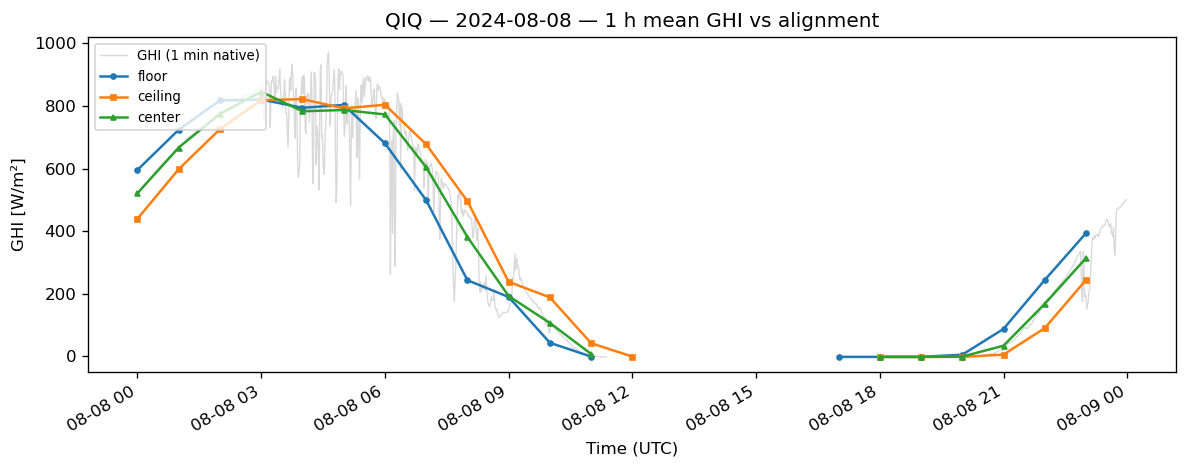

In [9]:
day = "2024-08-08"
sub = slice(f"{day} 00:00", f"{day} 23:59")

fig, ax = plt.subplots(figsize=(10, 4), dpi=120)

if "ghi" in ds.data().columns:
    ax.plot(
        ds.data().loc[sub].index,
        ds.data().loc[sub, "ghi"],
        color="0.85",
        linewidth=0.8,
        label="GHI (1 min native)",
    )

ax.plot(avg_floor.loc[sub].index, avg_floor.loc[sub, "ghi"], marker="o", markersize=3, label="floor")
ax.plot(avg_ceil.loc[sub].index, avg_ceil.loc[sub, "ghi"], marker="s", markersize=3, label="ceiling")
ax.plot(avg_center.loc[sub].index, avg_center.loc[sub, "ghi"], marker="^", markersize=3, label="center")

ax.set_ylabel("GHI [W/m²]")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"{stn} — {day} — 1 h mean GHI vs alignment")
ax.legend(loc="upper left", fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 8. Optional: compare clear-sky GHI / 可选：比较晴空 GHI

Same overlay for **`ghi_clear`** (REST2).

对 **`ghi_clear`**（REST2）做同样叠加。


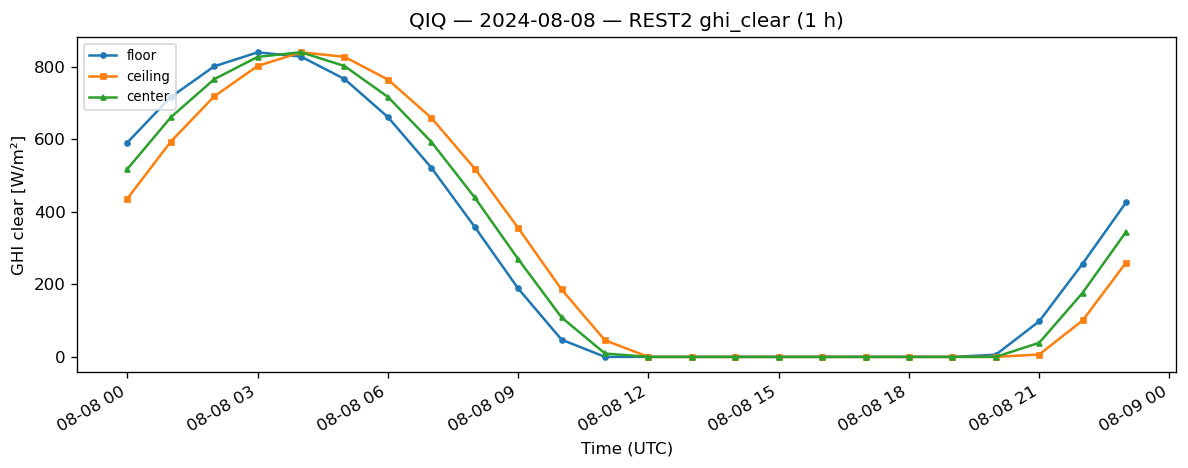

In [10]:
if "ghi_clear" in avg_floor.columns:
    fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
    ax.plot(avg_floor.loc[sub].index, avg_floor.loc[sub, "ghi_clear"], marker="o", markersize=3, label="floor")
    ax.plot(avg_ceil.loc[sub].index, avg_ceil.loc[sub, "ghi_clear"], marker="s", markersize=3, label="ceiling")
    ax.plot(avg_center.loc[sub].index, avg_center.loc[sub, "ghi_clear"], marker="^", markersize=3, label="center")
    ax.set_ylabel("GHI clear [W/m²]")
    ax.set_xlabel("Time (UTC)")
    ax.set_title(f"{stn} — {day} — REST2 ghi_clear (1 h)")
    ax.legend(loc="upper left", fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()